D:\Conda\envs\GenAI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


***************************************************************************************************
MTL, 1/1 time
***************************************************************************************************
3756 470 470 1
Molecule graph generation is complete !


E:\manuscript\水生毒性的集成预测\JSS-Manuscript-Interpretable Aquatic Toxicity Screening with Multi-Task Graph Convolutional Network Guided Attention Mechanism\修改手稿\第七次修改\建模\interpretation\..\utils\GNN.py:480: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:264.)
  labels = torch.tensor(labels)


Tasks: 0 FishAT **********************
Predict values: tensor(0.2463, device='cuda:0')
True values: tensor(1., device='cuda:0')
Nc1ccc(S(=O)(=O)Nc2ccc(Cl)nn2)cc1


[19:22:40] The new font size 1 is below the current minimum (6).


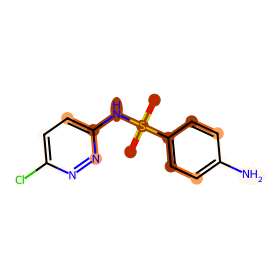

Tasks: 0 FishAT **********************
Predict values: tensor(0.8700, device='cuda:0')
True values: tensor(1., device='cuda:0')
Nc1c(Cl)cccc1Cl


[19:22:41] The new font size 1 is below the current minimum (6).


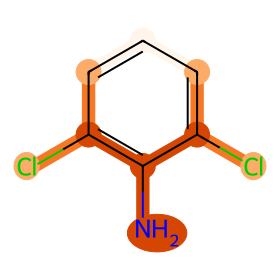

Tasks: 0 FishAT **********************
Predict values: tensor(0.8223, device='cuda:0')
True values: tensor(1., device='cuda:0')
Cc1ccc(N)c(Cl)c1


[19:22:41] The new font size 1 is below the current minimum (6).


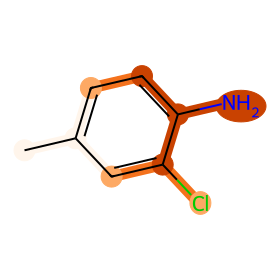

Tasks: 0 FishAT **********************
Predict values: tensor(0.9186, device='cuda:0')
True values: tensor(1., device='cuda:0')
Nc1c(Cl)cc(Cl)cc1Cl


[19:22:41] The new font size 1 is below the current minimum (6).


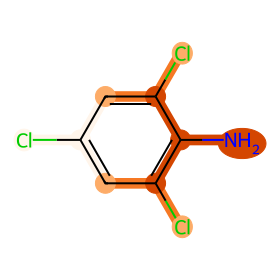

Tasks: 0 FishAT **********************
Predict values: tensor(0.9276, device='cuda:0')
True values: tensor(1., device='cuda:0')
Nc1cc(Cl)c(Cl)cc1Cl


[19:22:41] The new font size 1 is below the current minimum (6).


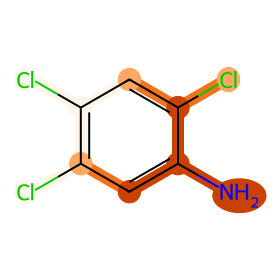

Tasks: 0 FishAT **********************
Predict values: tensor(0.8709, device='cuda:0')
True values: tensor(1., device='cuda:0')
Nc1ccc(Cl)cc1[N+](=O)[O-]


[19:22:41] The new font size 1 is below the current minimum (6).


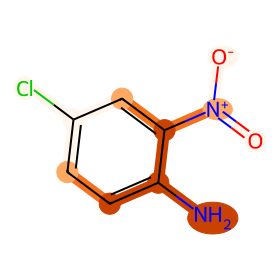

Tasks: 0 FishAT **********************
Predict values: tensor(0.3158, device='cuda:0')
True values: tensor(1., device='cuda:0')
Nc1cc(Cl)cc(C(=O)O)c1Cl


[19:22:41] The new font size 1 is below the current minimum (6).


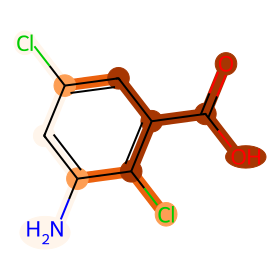

Tasks: 0 FishAT **********************
Predict values: tensor(0.9419, device='cuda:0')
True values: tensor(1., device='cuda:0')
Nc1c([N+](=O)[O-])ccc(Oc2ccccc2)c1Cl


[19:22:41] The new font size 1 is below the current minimum (6).


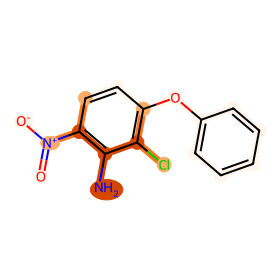

In [ ]:
# import numpy as np
import sys
sys.path.append('../')
from utils import build_dataset
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader
from utils.GNN import collate_molgraphs, EarlyStopping, run_an_eval_epoch_heterogeneous_return_weight,\
 set_random_seed, MGA, run_an_eval_epoch_heterogeneous_generate_weight
from utils.GNN import pos_weight
import os
import time
import pandas as pd

start = time.time()
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# fix parameters of model
args = {}
args['device'] = "cuda" if torch.cuda.is_available() else "cpu"
args['atom_data_field'] = 'atom'
args['bond_data_field'] = 'etype'
args['classification_metric_name'] = 'roc_auc'
args['regression_metric_name'] = 'r2'
# model parameter
args['num_epochs'] = 500
args['patience'] = 50
args['batch_size'] = 256
args['mode'] = 'higher'
args['in_feats'] = 40
args['rgcn_hidden_feats'] = [256, 128]
args['classifier_hidden_feats'] = 128
args['rgcn_drop_out'] = 0.4
args['drop_out'] = 0.3
args['lr'] = 3
args['weight_decay'] = 5
args['loop'] = True

# task name (model name)
args['task_name'] = 'MTL'  # change
args['data_name'] = 'AquaTox'  # change
args['times'] = 1

# selected task, generate select task index, task class, and classification_num
args['select_task_list'] = ['FishAT'] # change
args['select_task_index'] = []
args['classification_num'] = 0
args['regression_num'] = 0
args['all_task_list'] =['FishAT', 'CruAT', 'AlgAT', 'FishCT', 'CruCT', 'AlgCT']# change
# generate select task index
for index, task in enumerate(args['all_task_list']):
    if task in args['select_task_list']:
        args['select_task_index'].append(index)
# generate classification_num
for task in args['select_task_list']:
    if task in ['FishAT', 'CruAT', 'AlgAT', 'FishCT', 'CruCT', 'AlgCT']:
        args['classification_num'] = args['classification_num'] + 1
    if task in ['']:
        args['regression_num'] = args['regression_num'] + 1
# generate classification_num
if args['classification_num'] != 0 and args['regression_num'] != 0:
    args['task_class'] = 'classification_regression'
if args['classification_num'] != 0 and args['regression_num'] == 0:
    args['task_class'] = 'classification'
if args['classification_num'] == 0 and args['regression_num'] != 0:
    args['task_class'] = 'regression'

args['bin_path'] = '../data/' + args['data_name'] + '.bin'
args['group_path'] = '../data/' + args['data_name'] + '_group.csv'

result_pd = pd.DataFrame(columns=args['select_task_list'] + ['group'] + args['select_task_list'] + ['group']
                                 + args['select_task_list'] + ['group'])
all_times_train_result = []
all_times_val_result = []
all_times_test_result = []
for time_id in range(args['times']):
    set_random_seed(2020 + time_id)
    one_time_train_result = []
    one_time_val_result = []
    one_time_test_result = []
    print('***************************************************************************************************')
    print('{}, {}/{} time'.format(args['task_name'], time_id + 1, args['times']))
    print('***************************************************************************************************')
    train_set, val_set, test_set, task_number = build_dataset.load_graph_from_csv_bin_for_splited(
        bin_path=args['bin_path'],
        group_path=args['group_path'],
        select_task_index=args['select_task_index']
    )
    print("Molecule graph generation is complete !")
    train_loader = DataLoader(dataset=train_set,
                              batch_size=args['batch_size'],
                              shuffle=True,
                              collate_fn=collate_molgraphs)

    val_loader = DataLoader(dataset=val_set,
                            batch_size=args['batch_size'],
                            shuffle=True,
                            collate_fn=collate_molgraphs)

    test_loader = DataLoader(dataset=test_set,
                             batch_size=args['batch_size'],
                             collate_fn=collate_molgraphs)
    pos_weight_np = pos_weight(train_set, classification_num=args['classification_num'])
    loss_criterion_c = torch.nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight_np.to(args['device']))
    loss_criterion_r = torch.nn.MSELoss(reduction='none')
    model = MGA(in_feats=args['in_feats'], rgcn_hidden_feats=args['rgcn_hidden_feats'],
                n_tasks=6, rgcn_drop_out=args['rgcn_drop_out'],
                classifier_hidden_feats=args['classifier_hidden_feats'], dropout=args['drop_out'],
                loop=args['loop'], return_weight=True)
    optimizer = Adam(model.parameters(), lr=10 ** -args['lr'], weight_decay=10 ** -args['weight_decay'])
    stopper = EarlyStopping(patience=args['patience'], 
                            filename='../model/MTL-scr-256256128128_early_stop.pth',
                            task_name=args['task_name'], 
                            mode=args['mode'])
    model.to(args['device'])
    stopper.load_checkpoint(model)
    # selected test molecules
    selected_data = pd.read_csv('smarts_match_output/matched_both_substructures.csv')
    selected_mol_list = selected_data['smiles'].tolist()
    # visual test set
    run_an_eval_epoch_heterogeneous_return_weight(args, model, test_loader, vis_list=selected_mol_list)
    # run_an_eval_epoch_heterogeneous_generate_weight(args, model, test_loader)
